In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# STEP 1: Install and import required libraries
# Install required packages
!pip install prophet xgboost -q

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from prophet import Prophet

# Optional model interpretation
from sklearn.inspection import permutation_importance

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# STEP 2: Load the final prepared dataset from Phase 3
# Load the final prepared dataset from Phase 3
df = pd.read_csv('/content/drive/MyDrive/Dissertation Dataset/walmart_phase3_final.csv')

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ensure proper ordering
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (6255, 15)
   Store       Date   Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-03-05 1,554,806.6800             0      46.5000      2.6250   
1      1 2010-03-12 1,439,541.5900             0      57.7900      2.6670   
2      1 2010-03-19 1,472,515.7900             0      54.5800      2.7200   
3      1 2010-03-26 1,404,429.9200             0      51.4500      2.7320   
4      1 2010-04-02 1,594,968.2800             0      62.2700      2.7190   

       CPI  Unemployment          lag_1          lag_4  Month  Week  \
0 211.3501        8.1060 1,409,727.5900 1,643,690.9000      3     9   
1 211.3806        8.1060 1,554,806.6800 1,641,957.4400      3    10   
2 211.2156        8.1060 1,439,541.5900 1,611,968.1700      3    11   
3 211.0180        8.1060 1,472,515.7900 1,409,727.5900      3    12   
4 210.8204        7.8080 1,404,429.9200 1,554,806.6800      4    13   

   rolling_mean_4  rolling_std_4  Year  
0  1,554,614.9700   103,135.0025  2010  
1 

In [ ]:
# STEP 3: Final structural check
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print(df['Date'].min(), "to", df['Date'].max())



Column names:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'lag_1', 'lag_4', 'Month', 'Week', 'rolling_mean_4', 'rolling_std_4', 'Year']

Missing values:
Store             0
Date              0
Weekly_Sales      0
Holiday_Flag      0
Temperature       0
Fuel_Price        0
CPI               0
Unemployment      0
lag_1             0
lag_4             0
Month             0
Week              0
rolling_mean_4    0
rolling_std_4     0
Year              0
dtype: int64

Date range:
2010-03-05 00:00:00 to 2012-10-26 00:00:00


In [ ]:
# STEP 4: Define modelling features and target
features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'lag_1',
    'lag_4',
    'rolling_mean_4',
    'rolling_std_4',
    'Year',
    'Month',
    'Week'
]

target = 'Weekly_Sales'


In [ ]:
# STEP 5: Time-aware train-test split using unique dates

# Sort safely
df = df.sort_values(['Date', 'Store']).reset_index(drop=True)

# Use unique dates for an 80/20 chronological split
unique_dates = sorted(df['Date'].unique())
split_index = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_index]

train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Split date:", split_date)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training date range:", train['Date'].min(), "to", train['Date'].max())
print("Test date range:", test['Date'].min(), "to", test['Date'].max())

Split date: 2012-04-20 00:00:00
Training set shape: (4995, 13)
Test set shape: (1260, 13)
Training date range: 2010-03-05 00:00:00 to 2012-04-13 00:00:00
Test date range: 2012-04-20 00:00:00 to 2012-10-26 00:00:00


In [ ]:
# STEP 6: Prepare a common weekly comparison dataset for all models
# Aggregate actual test values by Date for final model comparison

actual_test_weekly = test.groupby('Date', as_index=False)['Weekly_Sales'].sum()
actual_test_weekly = actual_test_weekly.rename(columns={'Weekly_Sales': 'Actual_Weekly_Sales'})

print(actual_test_weekly.head())


        Date  Actual_Weekly_Sales
0 2012-04-20      45,072,529.7800
1 2012-04-27      43,716,798.8900
2 2012-05-04      47,124,197.9300
3 2012-05-11      46,925,878.9900
4 2012-05-18      46,823,939.2200


In [ ]:
# STEP 7: Create evaluation functions
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape_value = mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        'Model': [model_name],
        'RMSE': [rmse],
        'MAE': [mae],
        'MAPE (%)': [mape_value],
        'R²': [r2]
    })

In [ ]:
# STEP 8: Train Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred_row = rf_model.predict(X_test)

# Add predictions to test set
test_rf = test.copy()
test_rf['Pred_RF'] = rf_pred_row

# Aggregate predictions by Date
rf_weekly = test_rf.groupby('Date', as_index=False)['Pred_RF'].sum()

# Merge with actual weekly totals
rf_compare = actual_test_weekly.merge(rf_weekly, on='Date', how='inner')

results_rf = evaluate_model(
    "Random Forest",
    rf_compare['Actual_Weekly_Sales'],
    rf_compare['Pred_RF']
)

print(results_rf)

           Model           RMSE            MAE  MAPE (%)      R²
0  Random Forest 1,815,156.9069 1,444,502.9401    3.1418 -0.0620


In [ ]:
# STEP 9: TRAIN XGBOOST MODEL

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred_row = xgb_model.predict(X_test)

# Add predictions to test set
test_xgb = test.copy()
test_xgb['Pred_XGB'] = xgb_pred_row

# Aggregate predictions by Date
xgb_weekly = test_xgb.groupby('Date', as_index=False)['Pred_XGB'].sum()

# Merge with actual weekly totals
xgb_compare = actual_test_weekly.merge(xgb_weekly, on='Date', how='inner')

results_xgb = evaluate_model(
    "XGBoost",
    xgb_compare['Actual_Weekly_Sales'],
    xgb_compare['Pred_XGB']
)

print(results_xgb)

     Model           RMSE          MAE  MAPE (%)     R²
0  XGBoost 1,270,983.7472 918,514.7850    1.9781 0.4793


In [ ]:
# STEP 10: TRAIN PROPHET MODEL

# Aggregate full dataset to weekly total sales
prophet_df = df.groupby('Date', as_index=False)['Weekly_Sales'].sum()
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
prophet_df = prophet_df.sort_values('ds').reset_index(drop=True)

# Create holiday dataframe from Holiday_Flag
holiday_dates = df[df['Holiday_Flag'] == 1]['Date'].drop_duplicates().sort_values()

holidays_df = pd.DataFrame({
    'holiday': 'retail_holiday',
    'ds': holiday_dates
})

# Use same split date from corrected Step 5
prophet_train = prophet_df[prophet_df['ds'] < split_date].copy()
prophet_test = prophet_df[prophet_df['ds'] >= split_date].copy()

print("Prophet train shape:", prophet_train.shape)
print("Prophet test shape:", prophet_test.shape)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays_df
)

prophet_model.fit(prophet_train)

future = prophet_test[['ds']].copy()
prophet_forecast = prophet_model.predict(future)

prophet_compare = prophet_test[['ds', 'y']].copy()
prophet_compare['Pred_Prophet'] = prophet_forecast['yhat'].values

results_prophet = evaluate_model(
    "Prophet",
    prophet_compare['y'],
    prophet_compare['Pred_Prophet']
)

print(results_prophet)

Prophet train shape: (111, 2)
Prophet test shape: (28, 2)
     Model           RMSE            MAE  MAPE (%)     R²
0  Prophet 1,403,605.4220 1,078,463.0974    2.3034 0.3650


In [ ]:
# STEP 11: COMBINE ALL MODEL EVALUATION RESULTS

results_all = pd.concat([results_prophet, results_rf, results_xgb], ignore_index=True)
results_all = results_all.sort_values('RMSE').reset_index(drop=True)

print("\nFinal model comparison:")
print(results_all)


Final model comparison:
           Model           RMSE            MAE  MAPE (%)      R²
0        XGBoost 1,270,983.7472   918,514.7850    1.9781  0.4793
1        Prophet 1,403,605.4220 1,078,463.0974    2.3034  0.3650
2  Random Forest 1,815,156.9069 1,444,502.9401    3.1418 -0.0620


In [ ]:
# STEP 12: SAVE EVALUATION RESULTS

results_all.to_csv('/content/model_comparison_results.csv', index=False)
print("Results table saved successfully.")

Results table saved successfully.


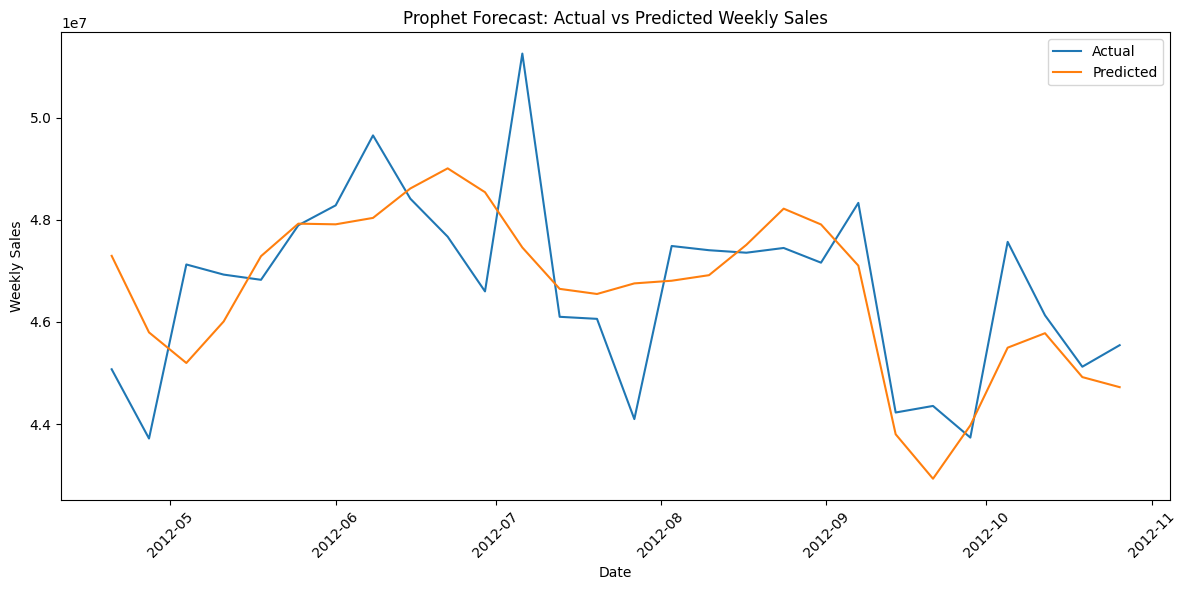

In [ ]:
# GRAPHICAL VISUALISATIONS
# STEP 13: PROPHET ACTUAL VS PREDICTED

plt.figure(figsize=(12, 6))
plt.plot(prophet_compare['ds'], prophet_compare['y'], label='Actual')
plt.plot(prophet_compare['ds'], prophet_compare['Pred_Prophet'], label='Predicted')
plt.title('Prophet Forecast: Actual vs Predicted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

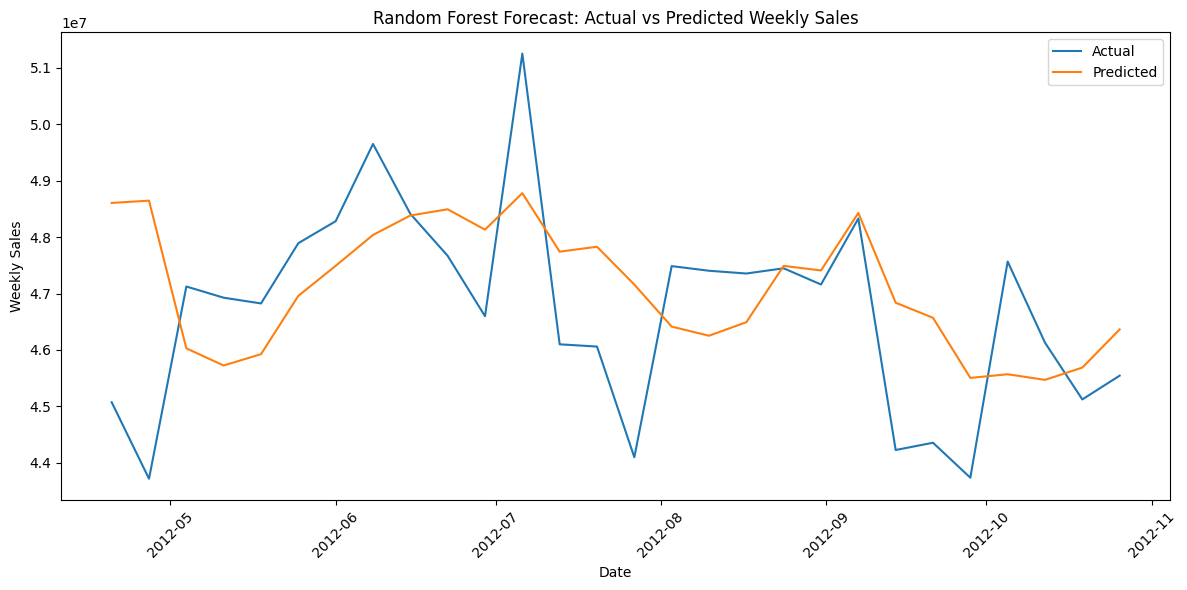

In [ ]:
# STEP 14: RANDOM FOREST ACTUAL VS PREDICTED

plt.figure(figsize=(12, 6))
plt.plot(rf_compare['Date'], rf_compare['Actual_Weekly_Sales'], label='Actual')
plt.plot(rf_compare['Date'], rf_compare['Pred_RF'], label='Predicted')
plt.title('Random Forest Forecast: Actual vs Predicted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

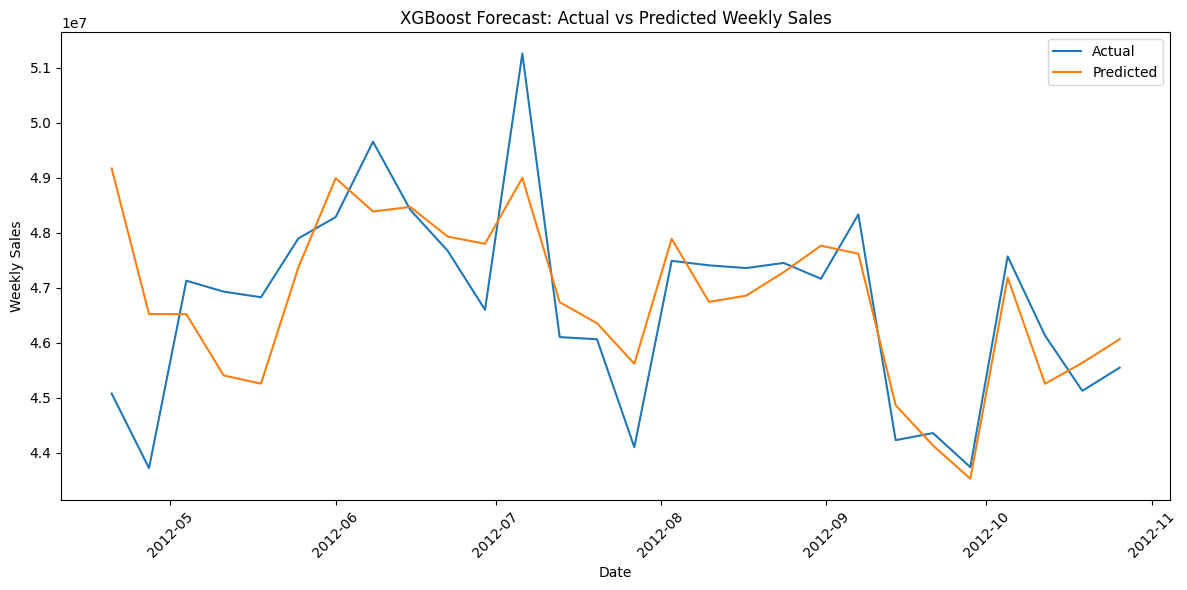

In [ ]:
# STEP 15: XGBOOST ACTUAL VS PREDICTED

plt.figure(figsize=(12, 6))
plt.plot(xgb_compare['Date'], xgb_compare['Actual_Weekly_Sales'], label='Actual')
plt.plot(xgb_compare['Date'], xgb_compare['Pred_XGB'], label='Predicted')
plt.title('XGBoost Forecast: Actual vs Predicted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

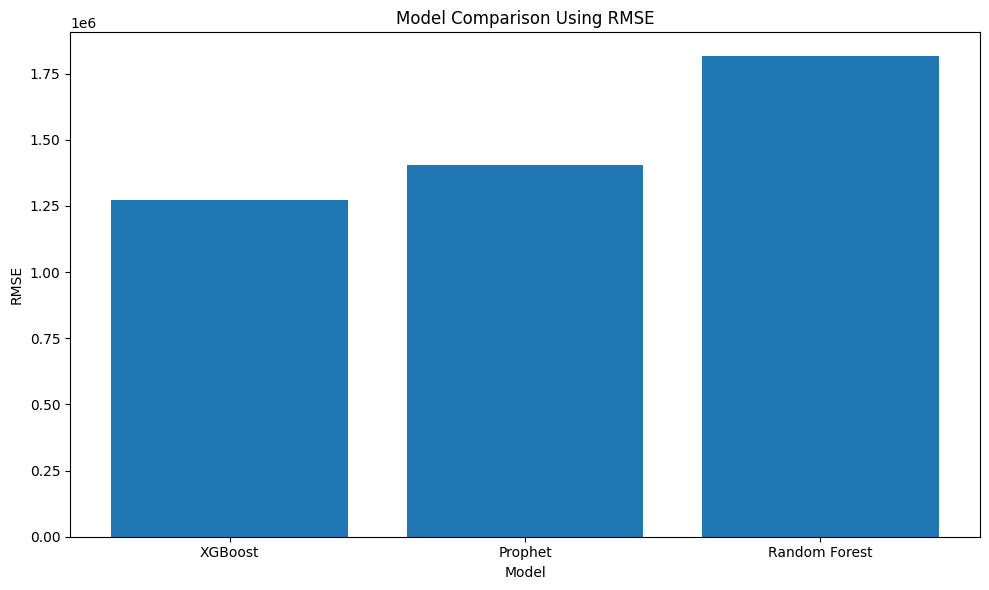

In [ ]:
# STEP 16: Comparative performance charts
# RMSE
plt.figure(figsize=(10, 6))
plt.bar(results_all['Model'], results_all['RMSE'])
plt.title('Model Comparison Using RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

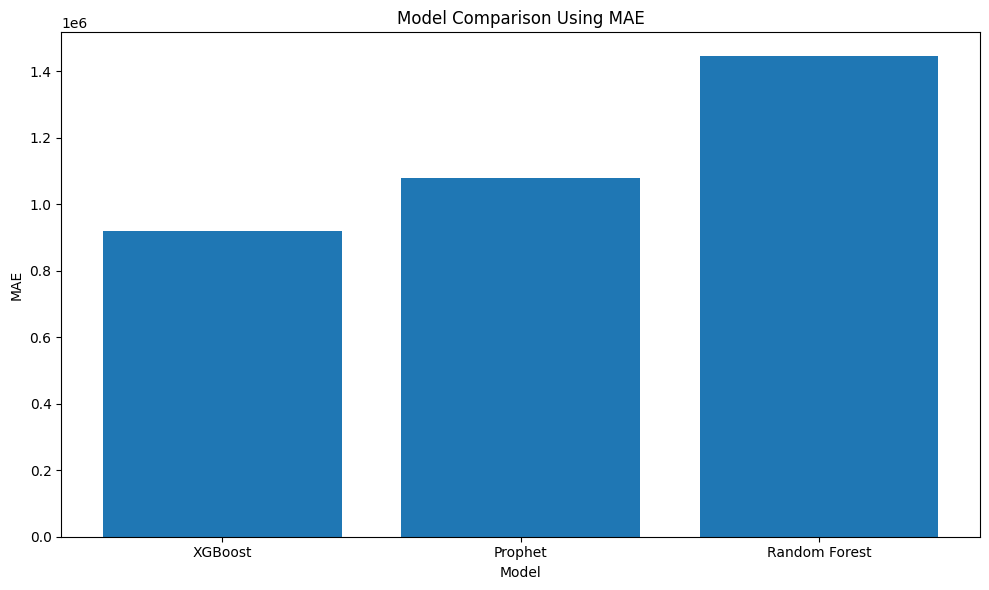

In [ ]:
# MAE
plt.figure(figsize=(10, 6))
plt.bar(results_all['Model'], results_all['MAE'])
plt.title('Model Comparison Using MAE')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

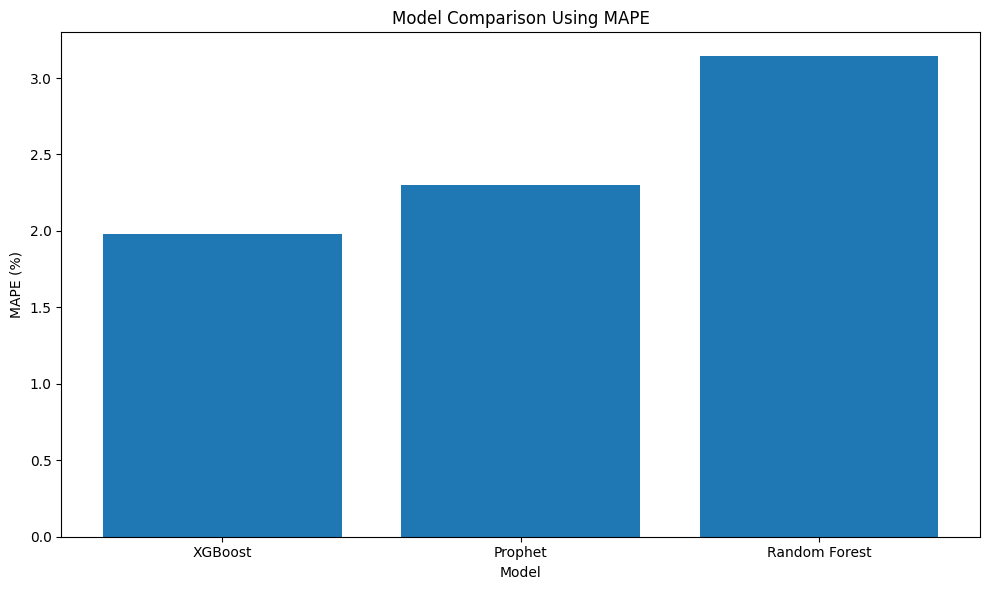

In [ ]:
# MAPE
plt.figure(figsize=(10, 6))
plt.bar(results_all['Model'], results_all['MAPE (%)'])
plt.title('Model Comparison Using MAPE')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.tight_layout()
plt.show()

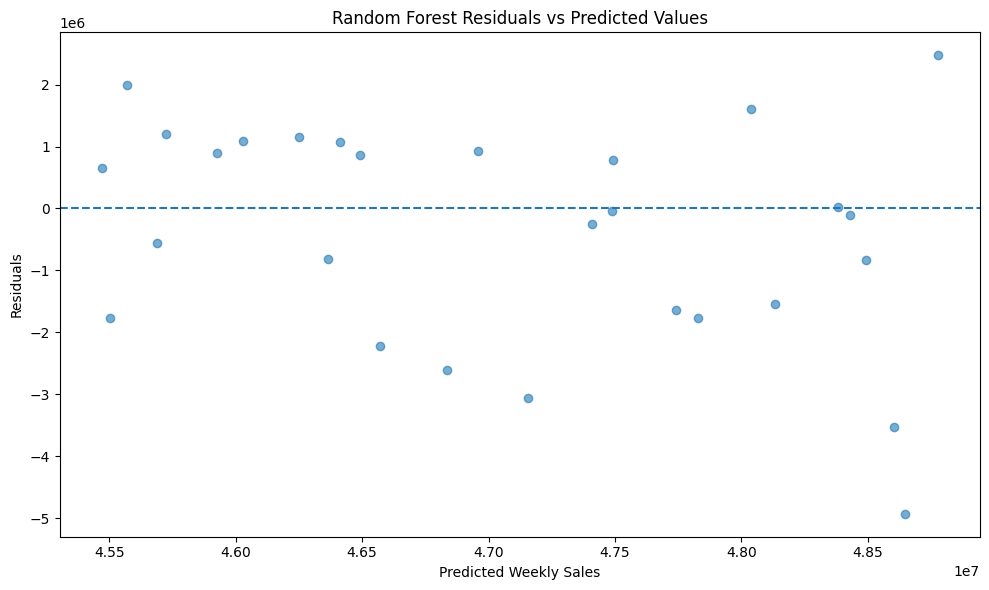

In [ ]:
# MODEL CHECKS / DIAGNOSTICS
# STEP 17: RESIDUAL ANALYSIS FOR RANDOM FOREST

rf_compare['Residual_RF'] = rf_compare['Actual_Weekly_Sales'] - rf_compare['Pred_RF']

plt.figure(figsize=(10, 6))
plt.scatter(rf_compare['Pred_RF'], rf_compare['Residual_RF'], alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('Random Forest Residuals vs Predicted Values')
plt.xlabel('Predicted Weekly Sales')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

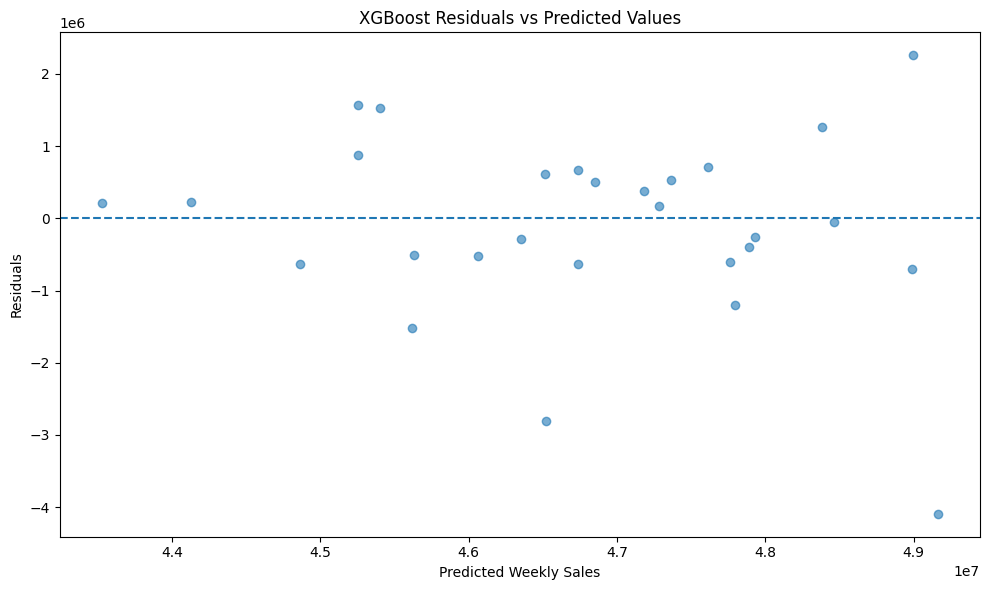

In [ ]:
# STEP 18: RESIDUAL ANALYSIS FOR XGBOOST

xgb_compare['Residual_XGB'] = xgb_compare['Actual_Weekly_Sales'] - xgb_compare['Pred_XGB']

plt.figure(figsize=(10, 6))
plt.scatter(xgb_compare['Pred_XGB'], xgb_compare['Residual_XGB'], alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('XGBoost Residuals vs Predicted Values')
plt.xlabel('Predicted Weekly Sales')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

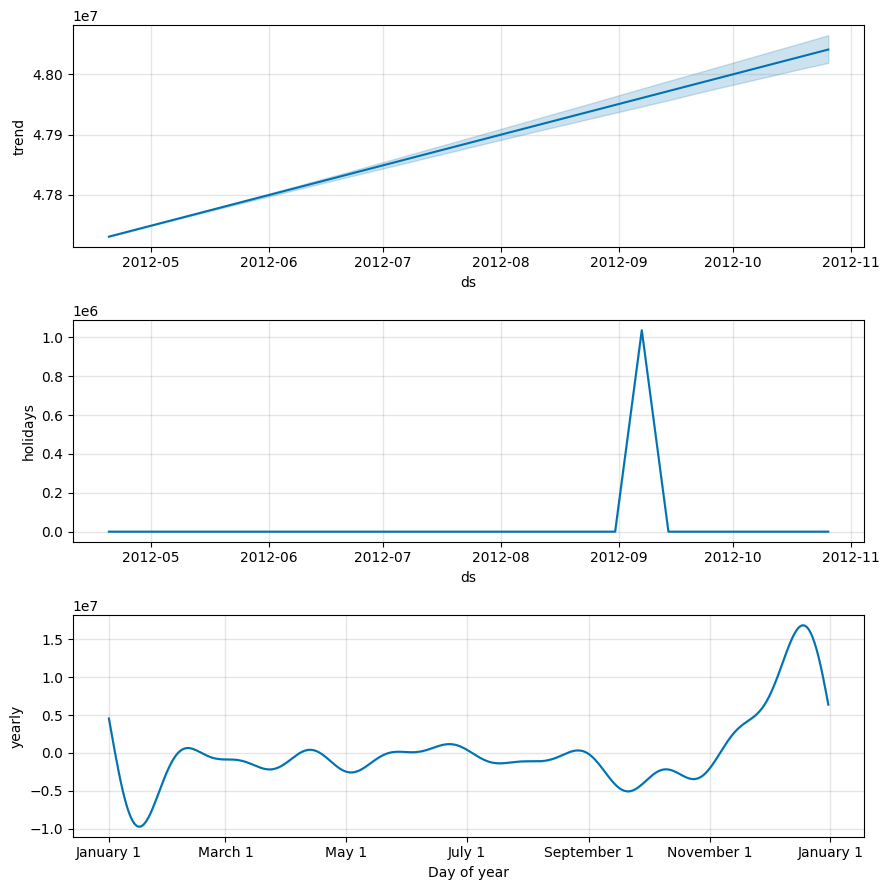

In [ ]:
# STEP 19: PROPHET COMPONENT PLOTS

prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

           Feature  Importance
8   rolling_mean_4      0.9473
9    rolling_std_4      0.0168
12            Week      0.0114
6            lag_1      0.0113
7            lag_4      0.0079
1     Holiday_Flag      0.0014
2      Temperature      0.0009
4              CPI      0.0007
11           Month      0.0007
5     Unemployment      0.0006
3       Fuel_Price      0.0005
0            Store      0.0004
10            Year      0.0001


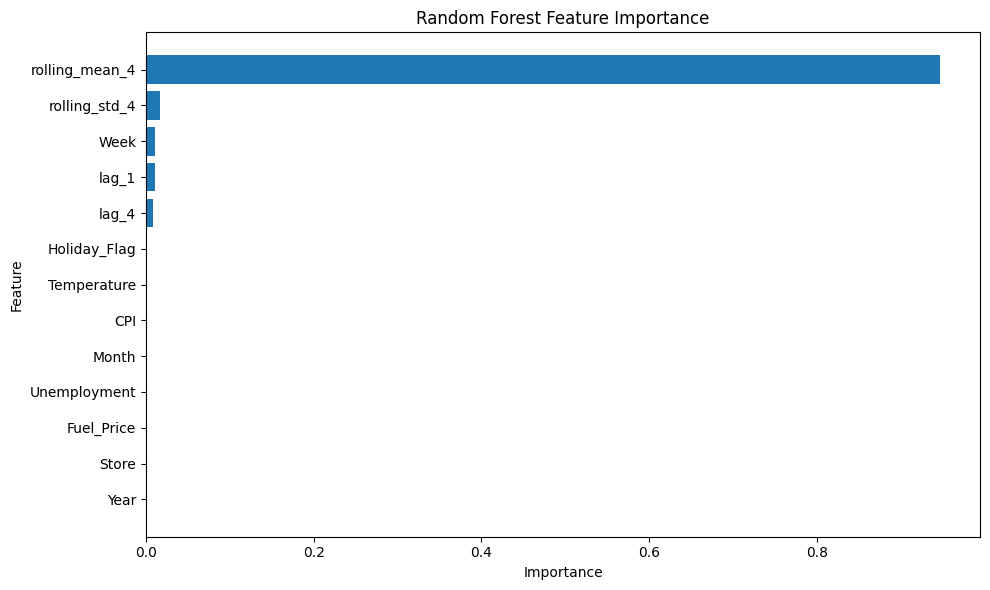

In [ ]:
# STEP 20: FEATURE IMPORTANCE — RANDOM FOREST

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

           Feature  Importance
8   rolling_mean_4      0.7292
6            lag_1      0.1710
7            lag_4      0.0409
12            Week      0.0233
1     Holiday_Flag      0.0107
11           Month      0.0099
9    rolling_std_4      0.0076
10            Year      0.0024
5     Unemployment      0.0012
0            Store      0.0010
3       Fuel_Price      0.0009
2      Temperature      0.0009
4              CPI      0.0008


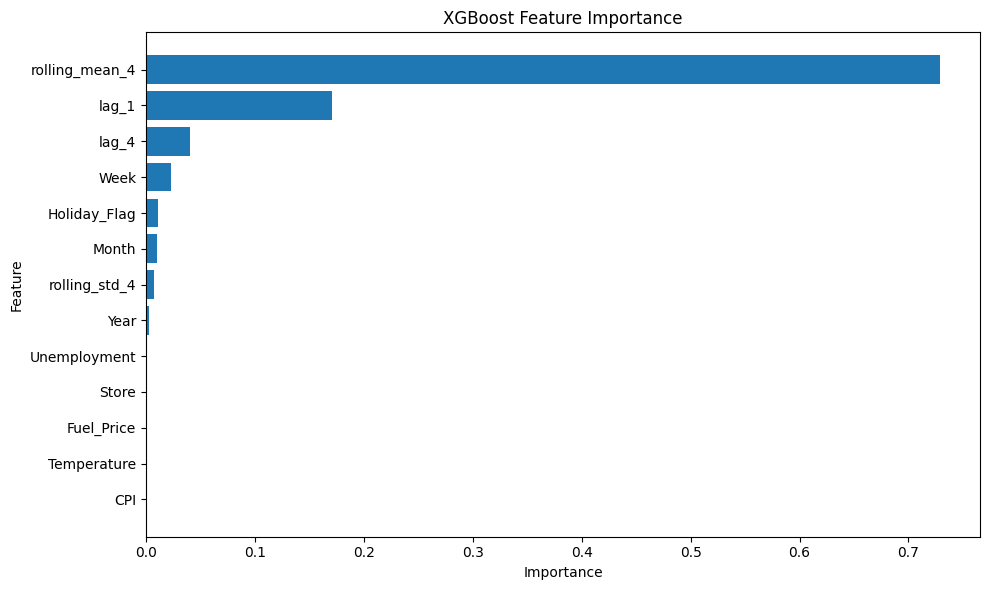

In [ ]:
# STEP 21: FEATURE IMPORTANCE — XGBOOST

xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(xgb_importance)

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

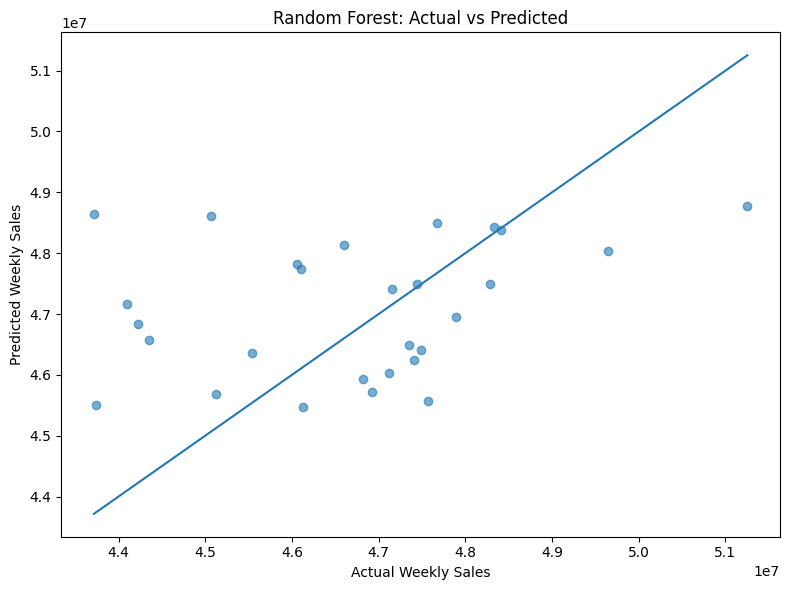

In [ ]:
# STEP 22: Actual vs predicted scatterplots
# Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(rf_compare['Actual_Weekly_Sales'], rf_compare['Pred_RF'], alpha=0.6)
plt.plot(
    [rf_compare['Actual_Weekly_Sales'].min(), rf_compare['Actual_Weekly_Sales'].max()],
    [rf_compare['Actual_Weekly_Sales'].min(), rf_compare['Actual_Weekly_Sales'].max()]
)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.tight_layout()
plt.show()


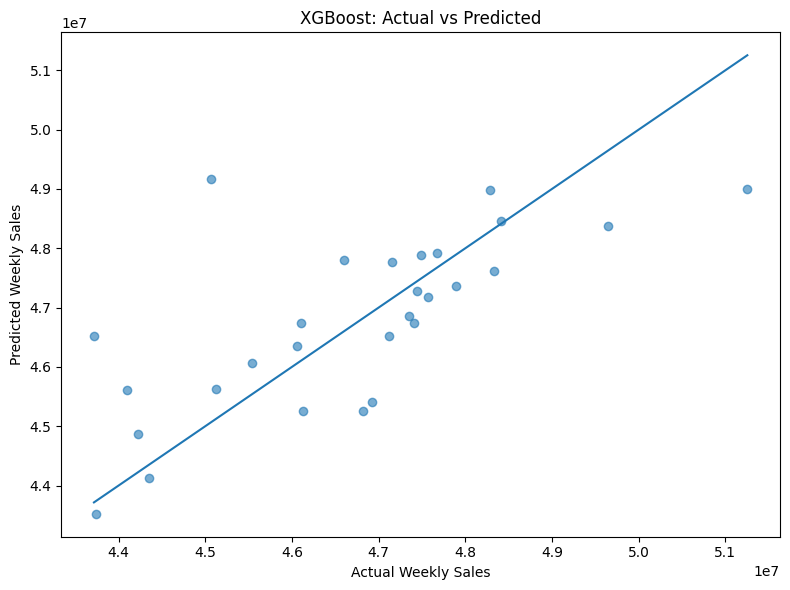

In [ ]:
# XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(xgb_compare['Actual_Weekly_Sales'], xgb_compare['Pred_XGB'], alpha=0.6)
plt.plot(
    [xgb_compare['Actual_Weekly_Sales'].min(), xgb_compare['Actual_Weekly_Sales'].max()],
    [xgb_compare['Actual_Weekly_Sales'].min(), xgb_compare['Actual_Weekly_Sales'].max()]
)
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.tight_layout()
plt.show()

In [ ]:
# STEP 23: EXPORT KEY COMPARISON FILES

rf_compare.to_csv('/content/rf_weekly_comparison.csv', index=False)
xgb_compare.to_csv('/content/xgb_weekly_comparison.csv', index=False)
prophet_compare.to_csv('/content/prophet_weekly_comparison.csv', index=False)
rf_importance.to_csv('/content/rf_feature_importance.csv', index=False)
xgb_importance.to_csv('/content/xgb_feature_importance.csv', index=False)

print("All comparison outputs exported successfully.")

All comparison outputs exported successfully.
